<a href="https://www.kaggle.com/code/mohamedmustafashaban/ai-workforce-displacement-prediction?scriptVersionId=319556209" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

# 2. Load data

In [2]:
train_df = pd.read_csv('/kaggle/input/datasets/itszubi/ai-workforce-displacement-and-automation-trends/ai_workforce_displacement_global_2020_2026.csv')
train_df.head()

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,...,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280,Research-calibrated synthetic data. Grounded i...
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,...,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559,Research-calibrated synthetic data. Grounded i...
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.198,...,0.0168,-0.0008,4,0.278,0.72,0.707,37,6.8,0.202,Research-calibrated synthetic data. Grounded i...
3,4,United States,USA,North America,High Income,2020,1,2020-Q1,Manufacturing & Industry,0.720,...,0.0642,-0.0282,47,0.268,0.29,0.310,50,6.8,0.655,Research-calibrated synthetic data. Grounded i...
4,5,United States,USA,North America,High Income,2020,1,2020-Q1,Retail & E-Commerce,0.676,...,0.0374,-0.0293,31,0.313,0.54,0.547,37,6.2,0.542,Research-calibrated synthetic data. Grounded i...


In [3]:
print("Data shape:", train_df.shape)

Data shape: (20800, 23)


# 3. Basic info and missing values

In [4]:
print(train_df.info())
print("\nMissing values:\n", train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   record_id                               20800 non-null  int64  
 1   country                                 20800 non-null  object 
 2   iso3_code                               20800 non-null  object 
 3   region                                  20800 non-null  object 
 4   income_group                            20800 non-null  object 
 5   year                                    20800 non-null  int64  
 6   quarter                                 20800 non-null  int64  
 7   quarter_label                           20800 non-null  object 
 8   industry_sector                         20800 non-null  object 
 9   sector_automation_risk_score            20800 non-null  float64
 10  gdp_per_capita_usd                      20800 non-null  in

# 4. Drop columns that are not useful for prediction

In [5]:
drop_cols = ['record_id', 'quarter_label', 'data_source_notes', 'country', 'iso3_code', 
             'region', 'quarter']  # categorical with many unique values
# Keep 'income_group' and 'industry_sector' as categorical features (maybe encode later)
train_df_clean = train_df.drop(columns=drop_cols, errors='ignore')
print("Columns after dropping:", train_df_clean.columns.tolist())

Columns after dropping: ['income_group', 'year', 'industry_sector', 'sector_automation_risk_score', 'gdp_per_capita_usd', 'ai_adoption_index', 'pct_sector_workforce_displaced', 'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct', 'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct', 'pct_workforce_female', 'pct_displaced_roles_female', 'reskilling_programs_count', 'govt_ai_policy_score_1_to_10', 'ai_tool_adoption_pct']


# 5. Handle missing values in numeric columns

In [6]:
numeric_cols = train_df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = train_df_clean.select_dtypes(include=['object']).columns

In [7]:
imputer_num = SimpleImputer(strategy='median')
train_df_clean[numeric_cols] = imputer_num.fit_transform(train_df_clean[numeric_cols])

In [8]:
for col in categorical_cols:
    train_df_clean[col] = train_df_clean[col].fillna(train_df_clean[col].mode()[0] if not train_df_clean[col].mode().empty else "Unknown")

In [9]:
print("Missing values after imputation:\n", train_df_clean.isnull().sum().sum())


Missing values after imputation:
 0


# 6. Exploratory Data Analysis

In [10]:
target = 'net_workforce_change_pct'
features = [c for c in train_df_clean.columns if c != target]

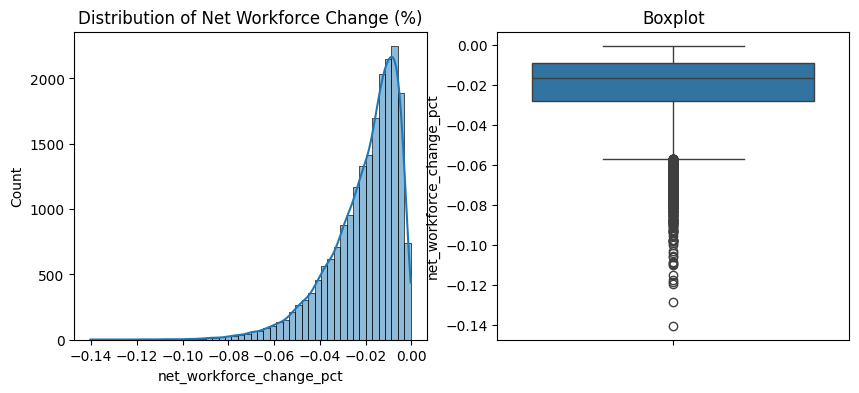

In [11]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(train_df_clean[target], bins=50, kde=True)
plt.title('Distribution of Net Workforce Change (%)')
plt.subplot(1,2,2)
sns.boxplot(y=train_df_clean[target])
plt.title('Boxplot')
plt.show()

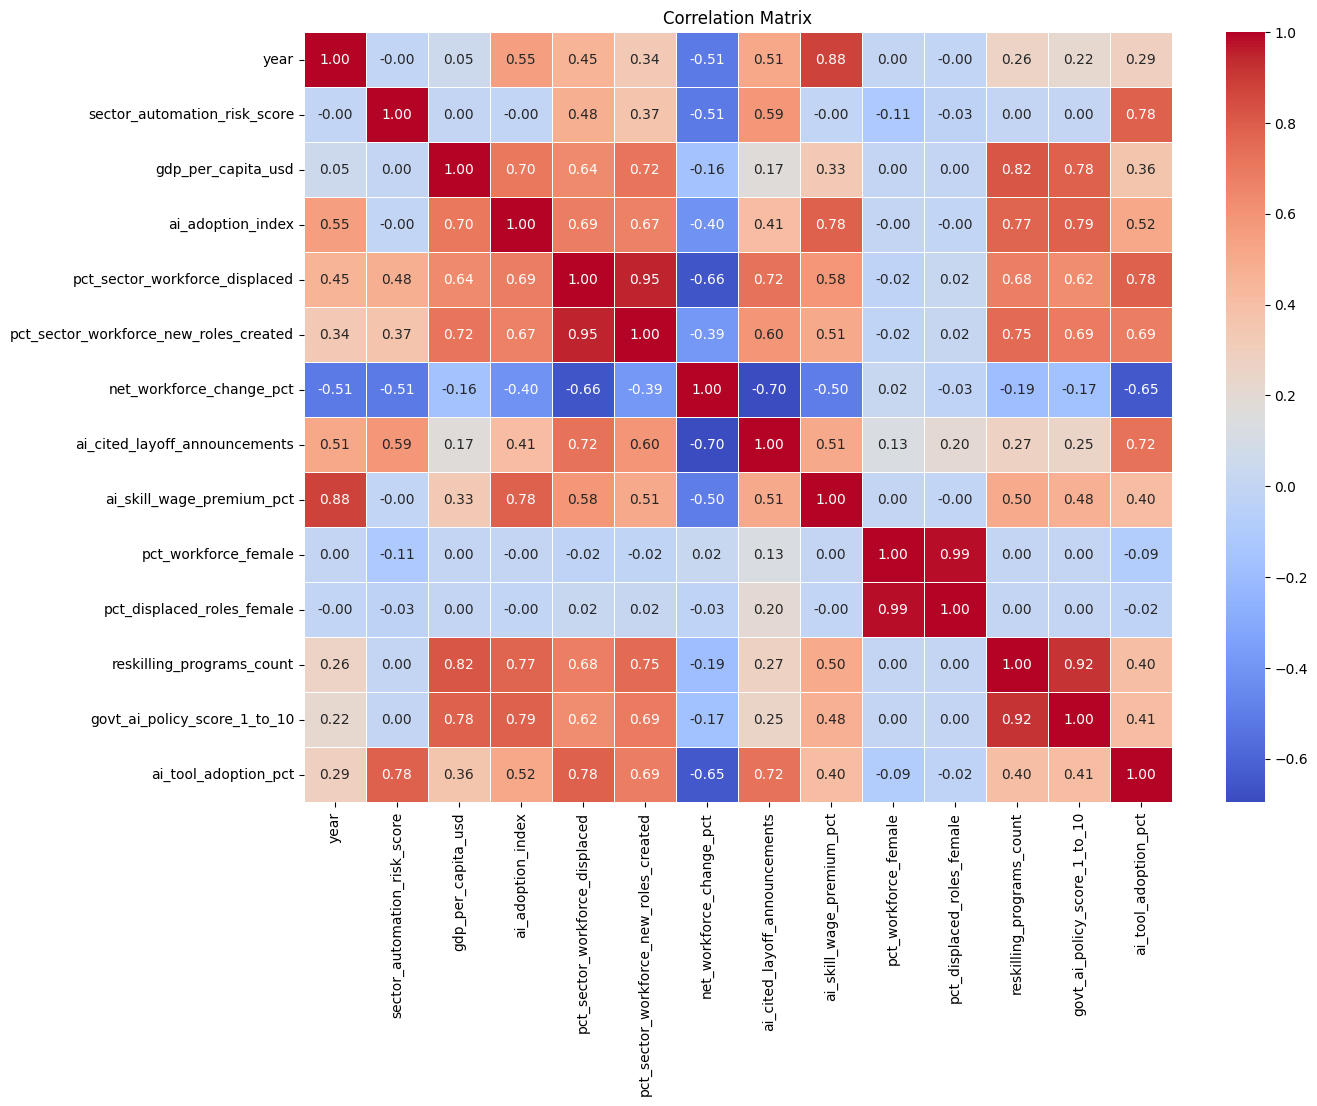

In [12]:
numeric_features = train_df_clean[numeric_cols].columns
plt.figure(figsize=(14,10))
corr = train_df_clean[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

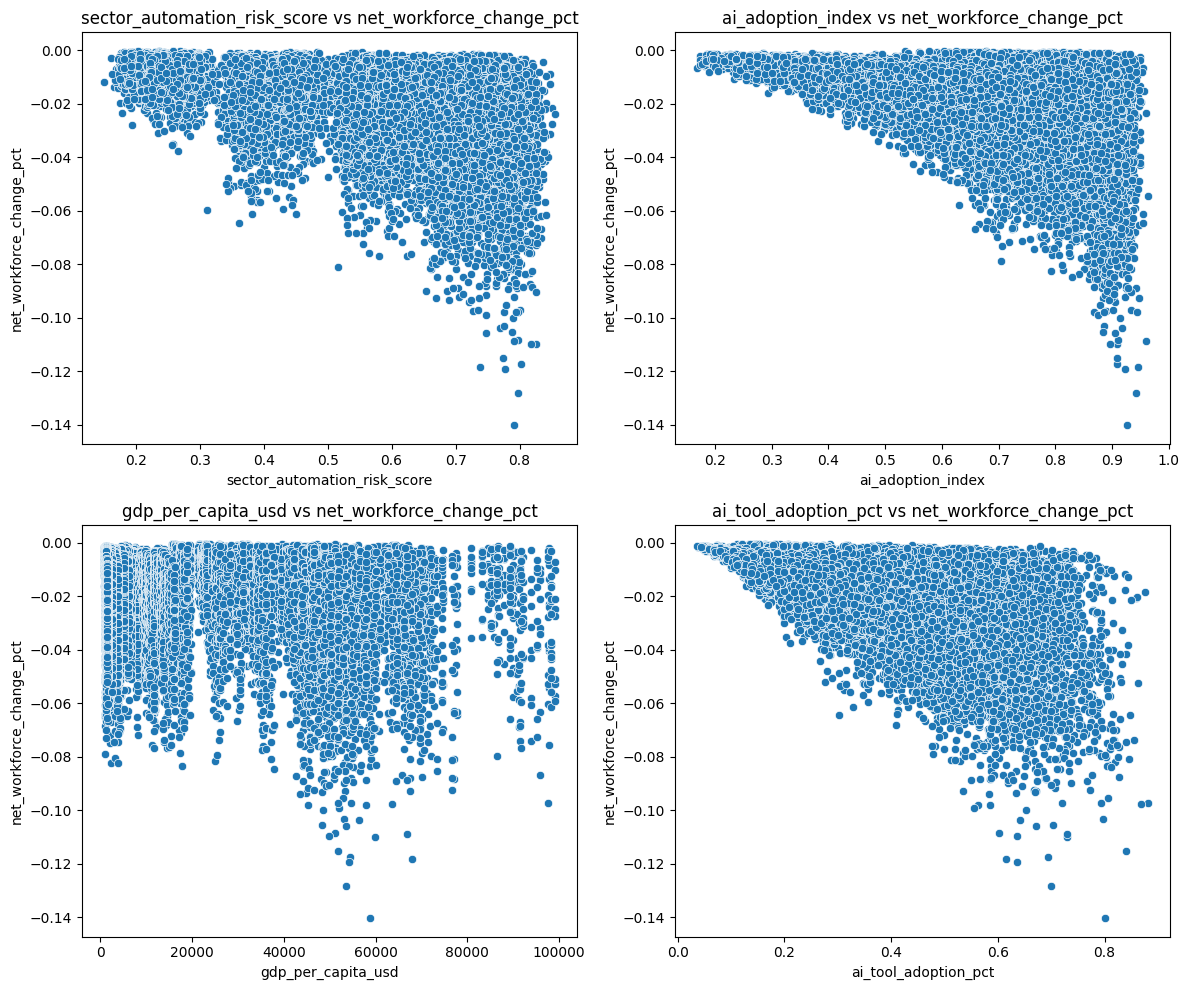

In [13]:
key_feats = ['sector_automation_risk_score', 'ai_adoption_index', 'gdp_per_capita_usd', 'ai_tool_adoption_pct']
fig, axes = plt.subplots(2,2, figsize=(12,10))
for i, feat in enumerate(key_feats):
    ax = axes[i//2, i%2]
    sns.scatterplot(data=train_df_clean, x=feat, y=target, ax=ax)
    ax.set_title(f'{feat} vs {target}')
plt.tight_layout()
plt.show()

# 7. Feature Engineering

In [14]:
train_df_clean['automation_risk_x_adoption'] = train_df_clean['sector_automation_risk_score'] * train_df_clean['ai_adoption_index']
train_df_clean['displaced_new_ratio'] = train_df_clean['pct_sector_workforce_displaced'] / (train_df_clean['pct_sector_workforce_new_roles_created'] + 0.01)
train_df_clean['policy_x_reskilling'] = train_df_clean['govt_ai_policy_score_1_to_10'] * train_df_clean['reskilling_programs_count']
train_df_clean['wage_premium_x_adoption'] = train_df_clean['ai_skill_wage_premium_pct'] * train_df_clean['ai_adoption_index']

In [15]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_df_clean[col] = le.fit_transform(train_df_clean[col])
    label_encoders[col] = le

print("New features added. Total features:", train_df_clean.shape[1])


New features added. Total features: 20


# 8. Prepare features and target

In [16]:
X = train_df_clean.drop(columns=[target])
y = train_df_clean[target]


In [17]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 9. Train multiple models and evaluate

In [19]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

In [20]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    results[name] = {'R2': r2, 'MAE': mae}
    print(f"{name}: R2 = {r2:.4f}, MAE = {mae:.4f}")

Random Forest: R2 = 0.9989, MAE = 0.0001
XGBoost: R2 = 0.9991, MAE = 0.0002
LightGBM: R2 = 0.9986, MAE = 0.0003
Gradient Boosting: R2 = 0.9979, MAE = 0.0005


# 10. Hyperparameter tuning (example for XGBoost)

In [21]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
xgb = XGBRegressor(random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)
print("Best XGBoost parameters:", grid.best_params_)
best_xgb = grid.best_estimator_


y_pred_best = best_xgb.predict(X_val_scaled)
print("Tuned XGBoost - R2:", r2_score(y_val, y_pred_best), "MAE:", mean_absolute_error(y_val, y_pred_best))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best XGBoost parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}
Tuned XGBoost - R2: 0.9991782539280478 MAE: 0.0001922746791620291


# 11. Ensemble model (Voting Regressor)

In [22]:

estimators = [
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('xgb', best_xgb),
    ('lgbm', LGBMRegressor(n_estimators=200, random_state=42, verbose=-1))
]
voting_reg = VotingRegressor(estimators)
voting_reg.fit(X_train_scaled, y_train)
y_pred_ensemble = voting_reg.predict(X_val_scaled)
print("Ensemble R2:", r2_score(y_val, y_pred_ensemble), "MAE:", mean_absolute_error(y_val, y_pred_ensemble))


Ensemble R2: 0.9992161725603933 MAE: 0.00014496473454587928


In [23]:
final_model = voting_reg
final_scaler = scaler
print("\nTo make a submission, load the test set, apply the same preprocessing, and predict with `final_model`.")


To make a submission, load the test set, apply the same preprocessing, and predict with `final_model`.


# 12. Feature importance from best XGBoost model

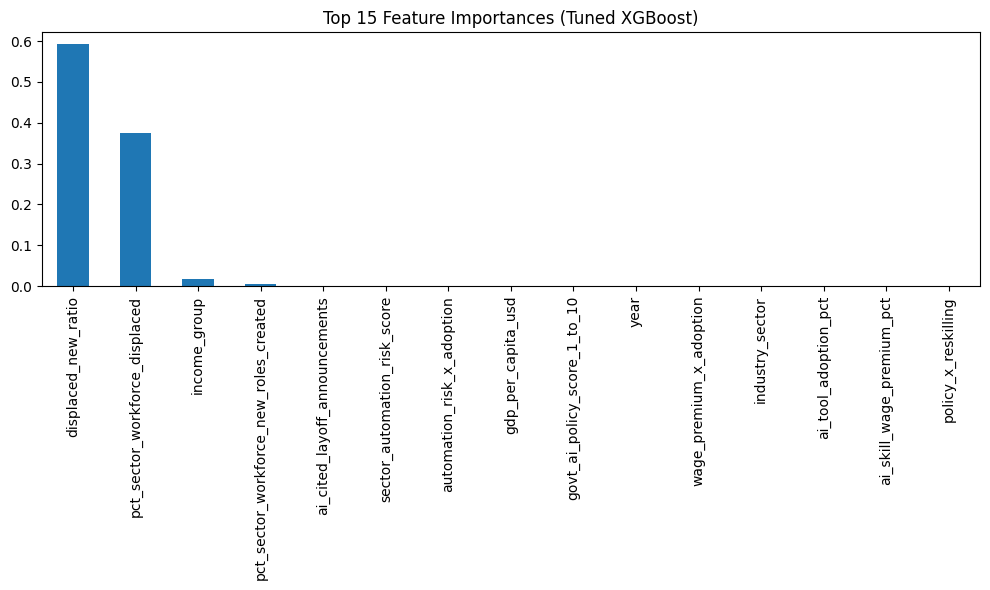

In [24]:

importances = best_xgb.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances (Tuned XGBoost)')
plt.tight_layout()
plt.show()

# 13. Save the model for later use (optional)

In [25]:
joblib.dump(final_model, 'final_model.pkl')
joblib.dump(final_scaler, 'scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.
